> **Superseded for production use, 2026-08-30.**
>
> This notebook builds the FD001-only baseline and is kept as the comparison
> point and as the record of how the module started. The model that feeds the
> Quality Steering Cell is now trained on all four CMAPSS subsets with temporal
> features, by `notebooks/01_timeseries/cmapss_full_fleet.py`.
>
> Three things here were measured to be wrong or incomplete once the full fleet
> was used, and they are worth reading before reusing anything from this file:
>
> 1. `cycle` is dropped from the features. It is a strong predictor of remaining
>    life and removing it cost about 1.7 RMSE.
> 2. The flat-sensor list is derived from FD001 alone. `s6`, `s10` and `s16` are
>    constant here but carry signal across the fleet.
> 3. There are no temporal features at all, so the model sees one snapshot at a
>    time. Adding rolling statistics over a 20-cycle window was worth 5.3 RMSE,
>    the single largest improvement in the module.
>
> Figures and the full decomposition: `docs/Model_Card_CMAPSS_RUL.md`.


# CMAPSS - RUL Prediction Model
**Arkon Manufacturing AI | Module: Time Series | Department: Engine Testing**

**Goal:** Train a Remaining Useful Life (RUL) regression model on CMAPSS FD001.

Approach:
1. Baseline: Linear Regression
2. Main model: XGBoost Regressor
3. Track all experiments with MLflow
4. Evaluate with RMSE, MAE, R²
5. Save best model

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import (
    get_device, get_mlflow_uri, save_figure,
    Timer, CheckpointManager, recommended_num_workers
)

print('arkon_utils loaded ✓')

arkon_utils loaded ✓


## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import mlflow
import mlflow.sklearn

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'timeseries'
PROC_DIR   = Path('../../data/01_cmapss/processed')
MODELS_DIR = Path('../../models/01_cmapss')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = Path('../../models/checkpoints/cmapss')


## 2. Connect to MLflow

In [3]:
# Connect to MLflow - platform-safe URI (works on Windows + Mac)
mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment('arkon-timeseries-cmapss')
print(f'MLflow URI   : {mlflow.get_tracking_uri()}')
print(f'Experiment   : arkon-timeseries-cmapss')


2026/08/11 17:31:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/11 17:31:08 INFO mlflow.store.db.utils: Updating database tables


2026/08/11 17:31:09 INFO mlflow.tracking.fluent: Experiment with name 'arkon-timeseries-cmapss' does not exist. Creating a new experiment.


MLflow URI   : sqlite:///D:/-PROJECTS/--Portfolio/arkon-manufacturing-ai/mlflow.db
Experiment   : arkon-timeseries-cmapss


## 3. Load Processed Data

In [4]:
# Load preprocessed train and test sets created in notebook 02
df_train = pd.read_csv(PROC_DIR / 'train_FD001_processed.csv')
df_test  = pd.read_csv(PROC_DIR / 'test_FD001_processed.csv')

print(f'Train: {df_train.shape} | Test: {df_test.shape}')
df_train.head(3)

Train: (20631, 20) | Test: (13096, 20)


,unit,cycle,os_1,os_2,os_3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125


## 4. Prepare Features & Target

In [5]:
# Separate feature columns from target (RUL) and ID columns (unit, cycle)
DROP_COLS = ['unit', 'cycle', 'RUL']
feature_cols = [c for c in df_train.columns if c not in DROP_COLS]

X_train = df_train[feature_cols].values
y_train = df_train['RUL'].values

X_test  = df_test[feature_cols].values
y_test  = df_test['RUL'].values

print(f'Features: {len(feature_cols)} | X_train: {X_train.shape} | X_test: {X_test.shape}')

Features: 17 | X_train: (20631, 17) | X_test: (13096, 17)


## 5. Helper Function - Evaluate & Log

In [6]:
# Helper function to compute metrics and log them to MLflow in one call
def evaluate(model, X, y, dataset_name='test'):
    preds = model.predict(X)
    rmse  = np.sqrt(mean_squared_error(y, preds))
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)
    print(f'{dataset_name:10s} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}')
    return preds, {'rmse': rmse, 'mae': mae, 'r2': r2}

## 6. Baseline - Linear Regression

In [7]:
# ── Checkpoint: skip training if model already saved ─────────────────
ckpt = CheckpointManager(CKPT_DIR)

if ckpt.exists('cmapss_lr_baseline'):
    lr, meta_lr = ckpt.load_sklearn('cmapss_lr_baseline')
    print(f'Loaded LR from checkpoint  | train time was: {meta_lr.get("train_time", "?")}')
else:
    with mlflow.start_run(run_name='baseline_linear_regression'):
        lr = LinearRegression()
        with Timer('Linear Regression training') as t_lr:
            lr.fit(X_train, y_train)

        preds_lr = lr.predict(X_test)
        rmse_lr  = np.sqrt(mean_squared_error(y_test, preds_lr))
        mae_lr   = mean_absolute_error(y_test, preds_lr)
        r2_lr    = r2_score(y_test, preds_lr)

        mlflow.log_params({'model': 'LinearRegression'})
        mlflow.log_metrics({'rmse': rmse_lr, 'mae': mae_lr, 'r2': r2_lr})
        mlflow.log_param('train_time_s', t_lr.seconds)
        mlflow.sklearn.log_model(lr, name='model')

        meta_lr = {'train_time': t_lr.report(), 'rmse': round(rmse_lr, 4),
                   'mae': round(mae_lr, 4), 'r2': round(r2_lr, 4)}
        ckpt.save_sklearn(lr, 'cmapss_lr_baseline', metadata=meta_lr)
        print(f'LR: RMSE={rmse_lr:.2f}  MAE={mae_lr:.2f}  R²={r2_lr:.3f}')

# Predictions needed by later cells on both paths (fresh train or checkpoint)
preds_lr = lr.predict(X_test)

⏱  Linear Regression training time: 0.0s


2026/08/11 17:31:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Checkpoint saved → models\checkpoints\cmapss\cmapss_lr_baseline.pkl
LR: RMSE=20.79  MAE=16.69  R²=0.432


## 7. Main Model - XGBoost

In [8]:
xgb_params = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'random_state':     42,
    'n_jobs':           -1,
    'tree_method':      'hist',   # fast on both CPU and GPU
    # 'device': 'cuda',           # uncomment to use GPU for XGBoost
}

if ckpt.exists('cmapss_xgb_v1'):
    xgb, meta_xgb = ckpt.load_sklearn('cmapss_xgb_v1')
    preds_xgb = xgb.predict(X_test)
    print(f'Loaded XGBoost from checkpoint | train time was: {meta_xgb.get("train_time", "?")}')
else:
    with mlflow.start_run(run_name='xgboost_v1'):
        xgb = XGBRegressor(**xgb_params)
        with Timer('XGBoost training') as t_xgb:
            xgb.fit(X_train, y_train)

        preds_xgb = xgb.predict(X_test)
        rmse_xgb  = np.sqrt(mean_squared_error(y_test, preds_xgb))
        mae_xgb   = mean_absolute_error(y_test, preds_xgb)
        r2_xgb    = r2_score(y_test, preds_xgb)

        mlflow.log_params(xgb_params)
        mlflow.log_metrics({'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb})
        mlflow.log_param('train_time_s', t_xgb.seconds)
        mlflow.sklearn.log_model(xgb, name='model')

        meta_xgb = {'train_time': t_xgb.report(), 'rmse': round(rmse_xgb, 4),
                    'mae': round(mae_xgb, 4), 'r2': round(r2_xgb, 4)}
        ckpt.save_sklearn(xgb, 'cmapss_xgb_v1', metadata=meta_xgb)
        print(f'XGB: RMSE={rmse_xgb:.2f}  MAE={mae_xgb:.2f}  R²={r2_xgb:.3f}')

2026/08/11 17:31:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


⏱  XGBoost training time: 1.2s


  ✓ Checkpoint saved → models\checkpoints\cmapss\cmapss_xgb_v1.pkl
XGB: RMSE=17.11  MAE=12.04  R²=0.615


## 8. Visualise Predictions vs Actual RUL

  ✓ Saved → assets\timeseries\cmapss_model_pred_vs_actual.png


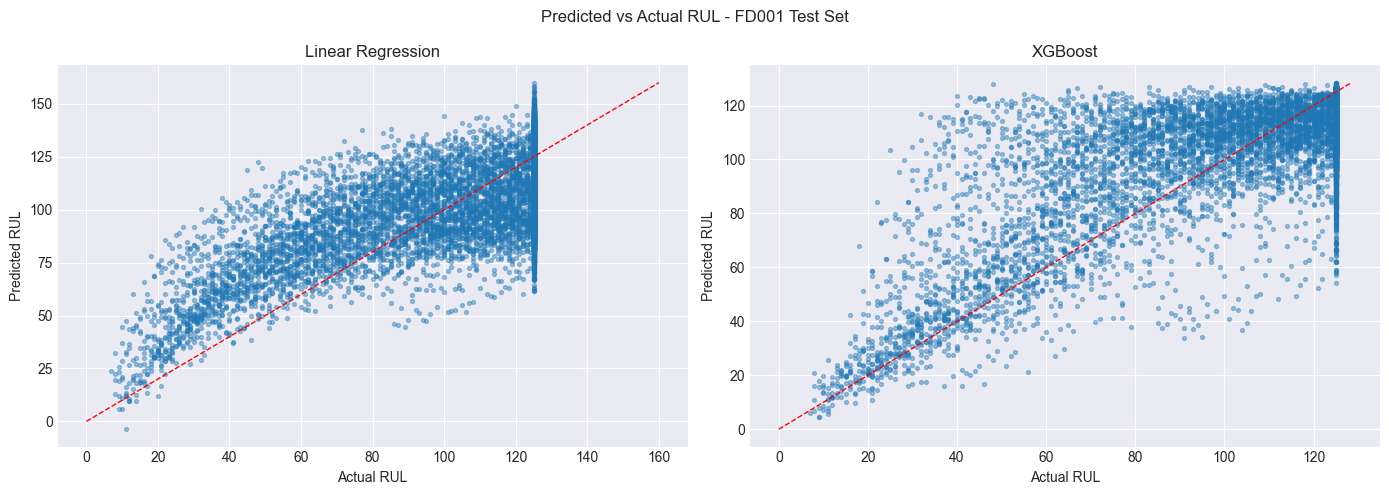

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, label in zip(axes, [preds_lr, preds_xgb], ['Linear Regression', 'XGBoost']):
    ax.scatter(y_test, preds, alpha=0.4, s=8)
    lim = [0, max(y_test.max(), preds.max())]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set_xlabel('Actual RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(label)
plt.suptitle('Predicted vs Actual RUL - FD001 Test Set')
plt.tight_layout()
save_figure(fig, 'cmapss_model_pred_vs_actual', subfolder=ASSETS)
plt.show()


## 9. Feature Importance

  ✓ Saved → assets\timeseries\cmapss_model_feature_importance.png


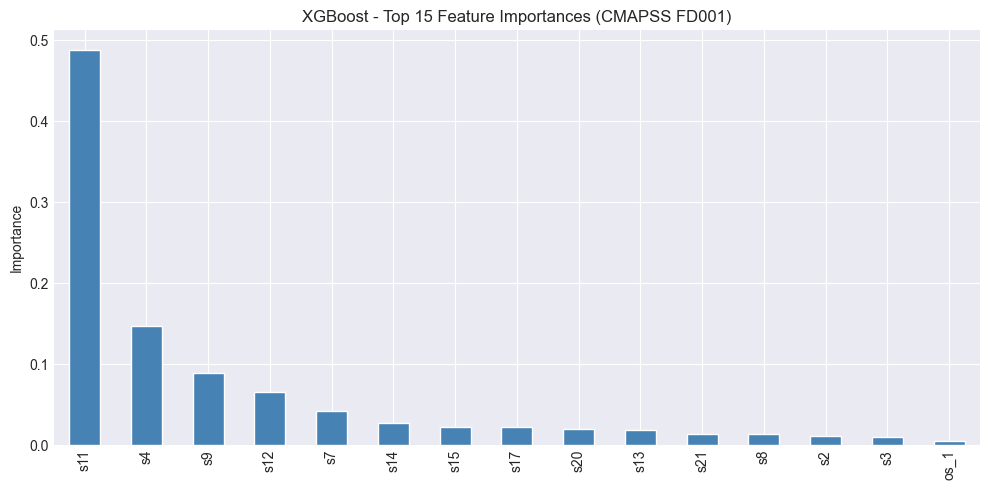

In [10]:
importance = pd.Series(xgb.feature_importances_, index=feature_cols)
top15 = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top15.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost - Top 15 Feature Importances (CMAPSS FD001)')
ax.set_ylabel('Importance')
plt.tight_layout()
save_figure(fig, 'cmapss_model_feature_importance', subfolder=ASSETS)
plt.show()


## 10. Engine-level Prediction Plot

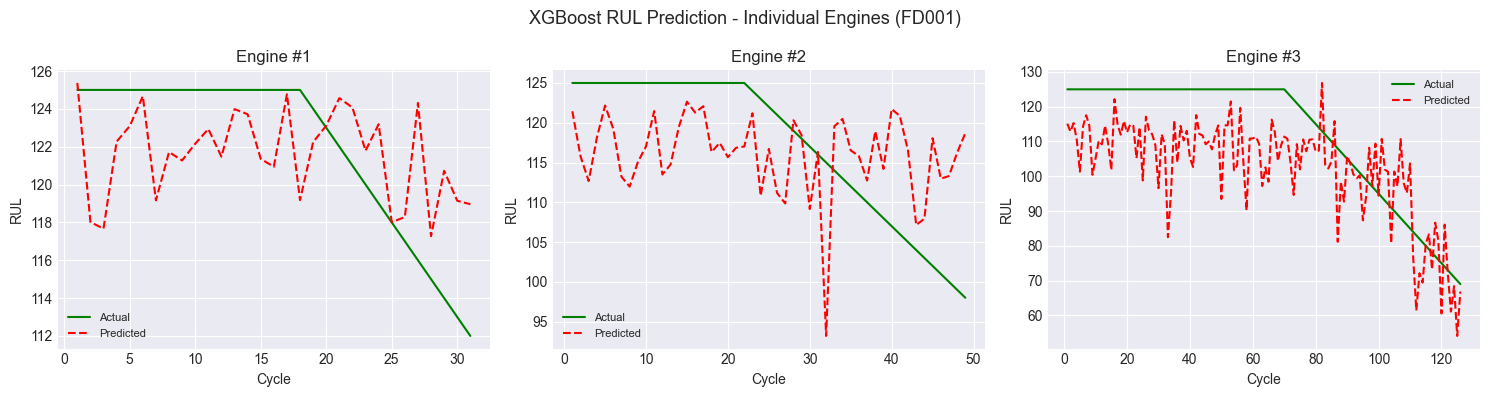

In [11]:
# Plot predicted vs actual RUL over time for 3 individual engines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_units = df_test['unit'].unique()[:3]
df_test_pred = df_test.copy()
df_test_pred['pred_RUL'] = preds_xgb

for ax, unit in zip(axes, sample_units):
    eng = df_test_pred[df_test_pred['unit'] == unit].sort_values('cycle')
    ax.plot(eng['cycle'], eng['RUL'],      label='Actual',    color='green')
    ax.plot(eng['cycle'], eng['pred_RUL'], label='Predicted', color='red', linestyle='--')
    ax.set_title(f'Engine #{unit}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend(fontsize=8)

plt.suptitle('XGBoost RUL Prediction - Individual Engines (FD001)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Save Best Model

In [12]:
# Save final XGBoost model to disk for use in Streamlit app
model_path = MODELS_DIR / 'cmapss_xgb_FD001.pkl'
joblib.dump(xgb, model_path)
print(f'Model saved to: {model_path}')

# Save test predictions for Tableau dashboard
df_test_pred[['unit', 'cycle', 'RUL', 'pred_RUL']].to_csv(
    PROC_DIR / 'test_FD001_predictions.csv', index=False
)
print('Predictions saved for Tableau/Streamlit.')

Model saved to: ..\..\models\01_cmapss\cmapss_xgb_FD001.pkl
Predictions saved for Tableau/Streamlit.


## 12. Results Summary

| Model | RMSE | MAE | R² | Train time |
|-------|------|-----|----|-----------|
| Linear Regression | 20.79 | 16.69 | 0.432 | 0.0s |
| XGBoost v1 | 17.11 | 12.04 | 0.615 | 1.2s |

Executed 2026-08-11 on Windows (FD001, RUL capped at 125, per-row evaluation on the full test set).

**Next step:** convert predictions to Arkon risk events (`events/make_events_cmapss.py`), then integrate into Streamlit page `02_timeseries.py`.

View all runs in MLflow UI: `mlflow ui --backend-store-uri sqlite:///mlflow.db` then **http://localhost:5000**

In [13]:
# ── Model comparison with training times ─────────────────────────────
import pandas as pd
results = pd.DataFrame([
    {'Model': 'Linear Regression', **meta_lr},
    {'Model': 'XGBoost v1',        **meta_xgb},
])
results = results[['Model', 'rmse', 'mae', 'r2', 'train_time']]
results.columns = ['Model', 'RMSE', 'MAE', 'R²', 'Train Time']
print(results.to_string(index=False))


            Model    RMSE     MAE     R² Train Time
Linear Regression 20.7854 16.6929 0.4320       0.0s
       XGBoost v1 17.1089 12.0415 0.6152       1.2s
